In [ ]:
import os
import warnings
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import statsmodels.api as sm

from darts.models import (
    AutoARIMA,
    NaiveSeasonal,
    RandomForestModel,
    SKLearnModel,
    TSMixerModel,
    XGBModel,
)
from scipy.stats import wilcoxon
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
from sklearn.svm import SVR

from functions.analysis_functions import (
    darts_pipeline,
    diebold_mariano_test,
    error_plot,
    evaluation,
    mean_expected_profit_sigmoid,
    plot_profit_curves_sigmoid,
    plot_test,
    profit_cv_score_sigmoid,
)

In [ ]:
REPO_ROOT = Path(__file__).parent
df_nn = pd.read_csv(REPO_ROOT / "final_dataset_nn.csv")
df_nn["date"] = pd.to_datetime(df_nn["date"])
df_nn = df_nn.sort_values("date").set_index("date")
cols_to_fill = df_nn.columns.difference(['quota_per_bid_lag_-1', 'quota_per_bid_growth_rate_lag_-1'])
df_nn[cols_to_fill] = df_nn[cols_to_fill].fillna(0)
df_nn["prev_quota_premium"] = df_nn["quota_premium"].shift(1)

y = df_nn["quota_premium_growth_rate"].astype(np.float32)
X = df_nn.drop(columns=['quota_premium_growth_rate','prev_quota_premium'])
date_real = X.index.copy()

X = X.reset_index(drop=True)
y = y.reset_index(drop=True)
df_nn = df_nn.reset_index(drop=True)
X.index.name = "t"
y.index.name = "t"

H = 96
X_train, X_test = X.iloc[:-H].astype(np.float32), X.iloc[-H:].astype(np.float32)
y_train, y_test = y.iloc[:-H].astype(np.float32), y.iloc[-H:].astype(np.float32)
prev_levels_train = df_nn['prev_quota_premium'].iloc[:-H]
prev_levels_test = df_nn['prev_quota_premium'].iloc[-H:]
actual_levels_train = df_nn['quota_premium'].iloc[:-H]
actual_levels_test = df_nn['quota_premium'].iloc[-H:]

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)
assert X_train.index.equals(y_train.index)
assert X_test.index.equals(y_test.index)
assert X_train.isna().sum().sum() == 0
assert y_train.isna().sum() == 0
assert y_test.isna().sum() == 0

In [ ]:
# AutoArima

arima_base_params = dict()
arima_pred, arima_model = darts_pipeline(
    model_cls=AutoARIMA,
    base_params=arima_base_params,
    X_train=None, y_train=y_train,
    X_test=None, y_test=y_test,
    param_grid=None,
    scale_features=False,
    scale_target=False,
    scoring_metric=mean_absolute_error)

arima_eval = evaluation(
    model_name="AutoARIMA",
    y_true=y_test.loc[arima_pred.index],
    y_pred=arima_pred,
    prev_levels_test=prev_levels_test.loc[arima_pred.index],
    actual_levels_test=actual_levels_test.loc[arima_pred.index],
)

if hasattr(arima_model, "model") and hasattr(arima_model.model, "model_"):
    spec = arima_model.model.model_
    p, q, P, Q, m, d, D = spec["arma"]   # statsforecast format
    print(f"Selected: ARIMA({p},{d},{q}) x ({P},{D},{Q})[{m}]")
    print("AIC:", spec.get("aic"), "AICc:", spec.get("aicc"), "BIC:", spec.get("bic"))
    print("Coefficients:", spec.get("coef"))

--- initial tuning (past_covariates only) ---
best_params: {}
RMSE in growth rates: 5.9274
MAE in growth rates: 4.1447
RMSE in absolute levels: 5415.1697
MAE in absolute levels: 3760.7400
Selected: ARIMA(0,0,2) x (0,0,0)[1]
AIC: 4444.53064191633 AICc: 4444.604442654338 BIC: 4461.748437126018
Coefficients: {'ma1': np.float64(-0.31611197778915034), 'ma2': np.float64(-0.0733725231363107), 'intercept': np.float64(1.1249110138093221)}


In [ ]:
# Random Walk (Darts): NaiveSeasonal(K=1)
rw_base_params = {"K": 1}
rw_pred, rw_model = darts_pipeline(
    model_cls=NaiveSeasonal,
    base_params=rw_base_params,
    X_train=None, y_train=actual_levels_train,
    X_test=None, y_test=actual_levels_test,
    param_grid=None,
    scale_features=False,
    scale_target=False,
    scoring_metric=mean_absolute_error,
)

rw_rmse = root_mean_squared_error(actual_levels_test.loc[rw_pred.index], rw_pred)
rw_mae = mean_absolute_error(actual_levels_test.loc[rw_pred.index], rw_pred)

#MAE: 3590.2917 RMSE: 4694.0878 for last 48
#MAE: 3823.1146 RMSE: 5209.9593 for all 96

--- initial tuning (past_covariates only) ---
best_params: {}


In [ ]:
enet_base_params = dict(
    lags=12,                 
    lags_past_covariates=12,   
    output_chunk_length=1,
    model=ElasticNet(
        alpha=0.01,          
        l1_ratio=0.5,        
        fit_intercept=True,
        max_iter=10000,
        random_state=42,
    ),
)

enet_param_grid = {
    "model__alpha": [0.1, 1, 2, 5, 10, 20, 30],
    "model__l1_ratio": [0, 0.2,0.4,0.6,0.8,1.0],
}

enet_pred, enet_model = darts_pipeline(
    model_cls=SKLearnModel,
    base_params=enet_base_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=enet_param_grid,
    scale_features=True,     
    scale_target=False,
    n_splits= 3,            
    scoring_metric=mean_absolute_error,
    validation_refit_each_step=False
)

--- initial tuning (past_covariates only) ---
best_params: {'model__alpha': 30, 'model__l1_ratio': 1.0}


In [ ]:
xgb_base_params = dict(
    lags=12,                 
    lags_past_covariates=12,  
    output_chunk_length=1,
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
)

xgb_param_grid = {
    "max_depth": [3, 5],
    "learning_rate": [0.01, 0.05],
    "n_estimators": [200, 500],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.1, 0.3, 0.5],
}

xgb_pred, xgb_model = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,    # trees don't need scaling
    scale_target=False,
    n_splits=3,
    scoring_metric=mean_absolute_error,
    validation_refit_each_step=False
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.3, 'subsample': 0.8}


In [ ]:
rf_base_params = dict(
    lags=12,                   
    lags_past_covariates=12,  
    output_chunk_length=1,
    n_estimators=800,
    max_depth=6,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
)

rf_param_grid = {
    "n_estimators": [800],
    "max_depth": [3, 5, 8],
    "min_samples_split": [5, 10],
    "min_samples_leaf": [2, 5],
    "max_features": ["sqrt"],
}

rf_pred, rf_model = darts_pipeline(
    model_cls=RandomForestModel,
    base_params=rf_base_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=rf_param_grid,
    scale_features=False,     # trees don't need scaling
    scale_target=False,
    n_splits=3,
    scoring_metric=mean_absolute_error,
    validation_refit_each_step=False
)

--- initial tuning (past_covariates only) ---
best_params: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 5, 'n_estimators': 800}


In [ ]:
svr_base_params = dict(
    lags=12,                   # y_{t-1}..y_{t-12}
    lags_past_covariates=12,   # X_{t-1}..X_{t-12}
    output_chunk_length=1,
    model=SVR(
        kernel="rbf",
        C=10.0,
        epsilon=0.1,
        gamma="scale",
    ),
)

svr_param_grid = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.3, 1.0, 3.0, 10.0, 30.0],
    "model__epsilon": [0.1, 0.5, 1, 2],
    "model__gamma": ["scale"],
}

svr_pred, svr_model = darts_pipeline(
    model_cls=SKLearnModel,
    base_params=svr_base_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=svr_param_grid,
    scale_features=True,      # important for SVR
    scale_target=False,
    n_splits=3,
    scoring_metric=mean_absolute_error,
    validation_refit_each_step=False
)

--- initial tuning (past_covariates only) ---
best_params: {'model__C': 1.0, 'model__epsilon': 2, 'model__gamma': 'scale', 'model__kernel': 'rbf'}


In [ ]:
xgb_base_params_sigmoid = dict(
    lags=12,
    lags_past_covariates=12,
    output_chunk_length=1,
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
    objective="reg:absoluteerror",
)

xgb_pred_sigmoid, xgb_model_sigmoid = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params_sigmoid,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,
    scale_target=False,
    n_splits=3,
    scoring_metric=lambda yt, yp: profit_cv_score_sigmoid(
        y_true_growth=yt,
        y_pred_growth=yp,
        prev_levels_lookup=prev_levels_train, 
        steepness=0.001,      
        max_demand=1,        
        base_margin=2000
    ),
    validation_refit_each_step=False,
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.3, 'subsample': 1.0}


In [ ]:
enet_eval = evaluation(
    model_name="Elastic_Net",
    y_true=y_test,
    y_pred=enet_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

xgb_eval = evaluation(
    model_name="XGB",
    y_true=y_test,
    y_pred=xgb_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

rf_eval = evaluation(
    model_name="RF",
    y_true=y_test,
    y_pred=rf_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

svr_eval = evaluation(
    model_name="SVR",
    y_true=y_test,
    y_pred=svr_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)


xgb_eval_sigmoid = evaluation(
    model_name="XGB Custom Loss",
    y_true=y_test,
    y_pred=xgb_pred_sigmoid,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)


eval_df = pd.concat([arima_eval, enet_eval, xgb_eval, rf_eval, svr_eval, xgb_eval_sigmoid], ignore_index=True)

RMSE in growth rates: 5.8371
MAE in growth rates: 4.0497
RMSE in absolute levels: 5263.1243
MAE in absolute levels: 3680.1845
RMSE in growth rates: 5.4607
MAE in growth rates: 4.0125
RMSE in absolute levels: 4962.2305
MAE in absolute levels: 3640.6800
RMSE in growth rates: 5.8293
MAE in growth rates: 4.1194
RMSE in absolute levels: 5177.3469
MAE in absolute levels: 3733.3866
RMSE in growth rates: 5.8493
MAE in growth rates: 4.1361
RMSE in absolute levels: 5230.2026
MAE in absolute levels: 3755.0130
RMSE in growth rates: 5.7067
MAE in growth rates: 4.0062
RMSE in absolute levels: 5064.3082
MAE in absolute levels: 3620.3243


In [ ]:
eval_df

,model,rmse_growth,mae_growth,rmse_levels,mae_levels
0,AutoARIMA,5.927428,4.144671,5415.169745,3760.740040
1,Elastic_Net,5.837063,4.049707,5263.124270,3680.184458
2,XGB,5.460699,4.012541,4962.230544,3640.680010
3,RF,5.829269,4.119351,5177.346946,3733.386593
4,SVR,5.849269,4.136145,5230.202645,3755.012964
5,XGB Custom Loss,5.706658,4.006230,5064.308195,3620.324266


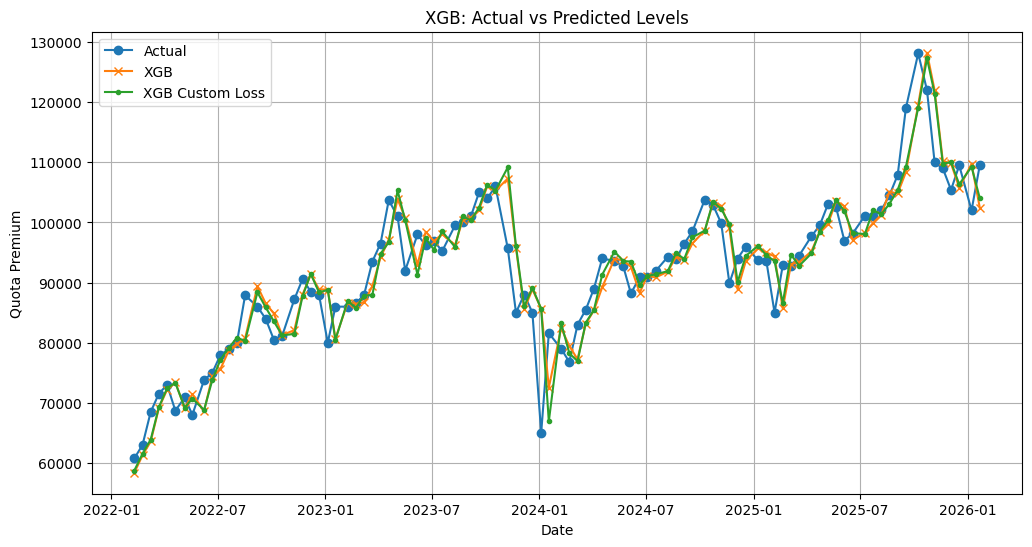

In [ ]:
xgb_pred_levels = prev_levels_test * (1 + xgb_pred / 100)
xgb_pred_sigmoid_levels = prev_levels_test * (1 + xgb_pred_sigmoid / 100)
arima_pred_levels = prev_levels_test * (1 + arima_pred / 100)

xgb_plot = plot_test(
    y_true=actual_levels_test,
    y_pred=xgb_pred_levels,
    y_pred_2=xgb_pred_sigmoid_levels,
    title="XGB: Actual vs Predicted Levels",
    xlabel="Time",
    ylabel="Quota Premium",
    y_pred_label="XGB",
    y_pred_2_label="XGB Custom Loss",
    date_real=date_real
)

In [ ]:
diebold_mariano_test(actual_levels_test, xgb_pred_levels, rw_pred, loss='abs')
diebold_mariano_test(actual_levels_test, xgb_pred_levels, arima_pred_levels, loss='abs')

diebold_mariano_test(actual_levels_test, xgb_pred_sigmoid_levels, rw_pred, loss='abs')
diebold_mariano_test(actual_levels_test, xgb_pred_sigmoid_levels, arima_pred_levels, loss='abs')

(np.float64(-0.7062936996016868), np.float64(0.4800055107036991))

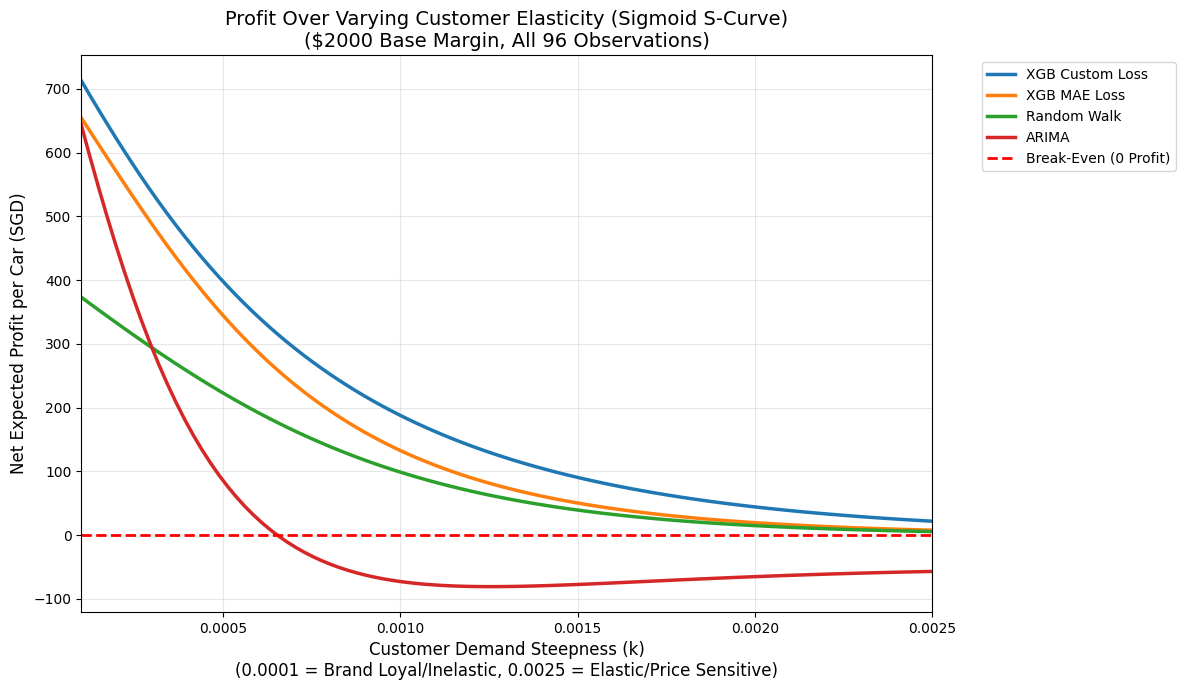

In [ ]:
plot_profit_curves_sigmoid(
    actual_levels=actual_levels_test,
    prev_levels=prev_levels_test,
    models_dict={
        "XGB Custom Loss": {"preds": xgb_pred_sigmoid_levels, "color": "tab:blue"},
        "XGB MAE Loss": {"preds": xgb_pred_levels, "color": "tab:orange"},
        "Random Walk": {"preds": rw_pred, "color": "tab:green"},
        "ARIMA": {"preds": arima_pred_levels, "color": "tab:red"},
    },
    base_margin=2000)

In [ ]:
profit_xgb = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
)
profit_xgb_sigmoid = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_sigmoid_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)
profit_rw = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=rw_pred,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)
profit_arima = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=arima_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)

In [ ]:
# 1. Calculate the difference in profit for each auction
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
constant = np.ones(len(d))
model = sm.OLS(endog=d, exog=constant)
hac_results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# 4. Extract the Diebold-Mariano Statistic and P-Value
dm_stat = hac_results.tvalues[0]
p_value = hac_results.pvalues[0]

print(f"Mean Profit Difference (XGB - RW): ${d.mean():.2f}")
print(f"Diebold-Mariano Statistic: {dm_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Mean Profit Difference (XGB - RW): $88.95
Diebold-Mariano Statistic: 1.9712
P-Value: 0.0487


In [ ]:
# Calculate the profit differences
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
# Perform the Wilcoxon signed-rank test
statistic, p_value = wilcoxon(d, alternative='two-sided')
print(f"Wilcoxon signed-rank test statistic: {statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

Wilcoxon signed-rank test statistic: 1624.0000
P-Value: 0.0149


In [ ]:
xgb_base_params = dict(
    lags=12,                 
    lags_past_covariates=12,  
    output_chunk_length=1,
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
)

xgb_param_grid = {
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [200, 300, 500],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.1, 0.3, 0.5],
}

xgb_pred, xgb_model = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,    # trees don't need scaling
    scale_target=False,
    n_splits=3,
    scoring_metric=mean_absolute_error,
    validation_refit_each_step=False
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'reg_alpha': 0.3, 'subsample': 0.8}


In [ ]:
xgb_base_params_sigmoid = dict(
    lags=12,
    lags_past_covariates=12,
    output_chunk_length=1,
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
    objective="reg:absoluteerror",
)

xgb_pred_sigmoid, xgb_model_sigmoid = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params_sigmoid,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,
    scale_target=False,
    n_splits=3,
    scoring_metric=lambda yt, yp: profit_cv_score_sigmoid(
        y_true_growth=yt,
        y_pred_growth=yp,
        prev_levels_lookup=prev_levels_train, 
        steepness=0.001,      
        max_demand=1,        
        base_margin=2000
    ),
    validation_refit_each_step=False,
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 300, 'reg_alpha': 0.1, 'subsample': 0.8}


In [ ]:
enet_eval = evaluation(
    model_name="Elastic_Net",
    y_true=y_test,
    y_pred=enet_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

xgb_eval = evaluation(
    model_name="XGB",
    y_true=y_test,
    y_pred=xgb_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

rf_eval = evaluation(
    model_name="RF",
    y_true=y_test,
    y_pred=rf_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

svr_eval = evaluation(
    model_name="SVR",
    y_true=y_test,
    y_pred=svr_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)


xgb_eval_sigmoid = evaluation(
    model_name="XGB Custom Loss",
    y_true=y_test,
    y_pred=xgb_pred_sigmoid,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)


eval_df = pd.concat([arima_eval, enet_eval, xgb_eval, rf_eval, svr_eval, xgb_eval_sigmoid], ignore_index=True)

RMSE in growth rates: 5.8371
MAE in growth rates: 4.0497
RMSE in absolute levels: 5263.1243
MAE in absolute levels: 3680.1845
RMSE in growth rates: 5.4607
MAE in growth rates: 4.0125
RMSE in absolute levels: 4962.2305
MAE in absolute levels: 3640.6800
RMSE in growth rates: 5.8293
MAE in growth rates: 4.1194
RMSE in absolute levels: 5177.3469
MAE in absolute levels: 3733.3866
RMSE in growth rates: 5.8493
MAE in growth rates: 4.1361
RMSE in absolute levels: 5230.2026
MAE in absolute levels: 3755.0130
RMSE in growth rates: 5.4926
MAE in growth rates: 3.9298
RMSE in absolute levels: 4958.5277
MAE in absolute levels: 3575.7861


In [ ]:
xgb_pred_sigmoid, xgb_model_sigmoid = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params_sigmoid,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,
    scale_target=False,
    n_splits=3,
    scoring_metric=lambda yt, yp: profit_cv_score_sigmoid(
        y_true_growth=yt,
        y_pred_growth=yp,
        prev_levels_lookup=prev_levels_train, 
        steepness=0.0005,      
        max_demand=1,        
        base_margin=2000
    ),
    validation_refit_each_step=False,
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 200, 'reg_alpha': 0.3, 'subsample': 1.0}


In [ ]:
xgb_eval_sigmoid = evaluation(
    model_name="XGB Custom Loss",
    y_true=y_test,
    y_pred=xgb_pred_sigmoid,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

RMSE in growth rates: 5.6694
MAE in growth rates: 4.0313
RMSE in absolute levels: 5048.3796
MAE in absolute levels: 3646.7680


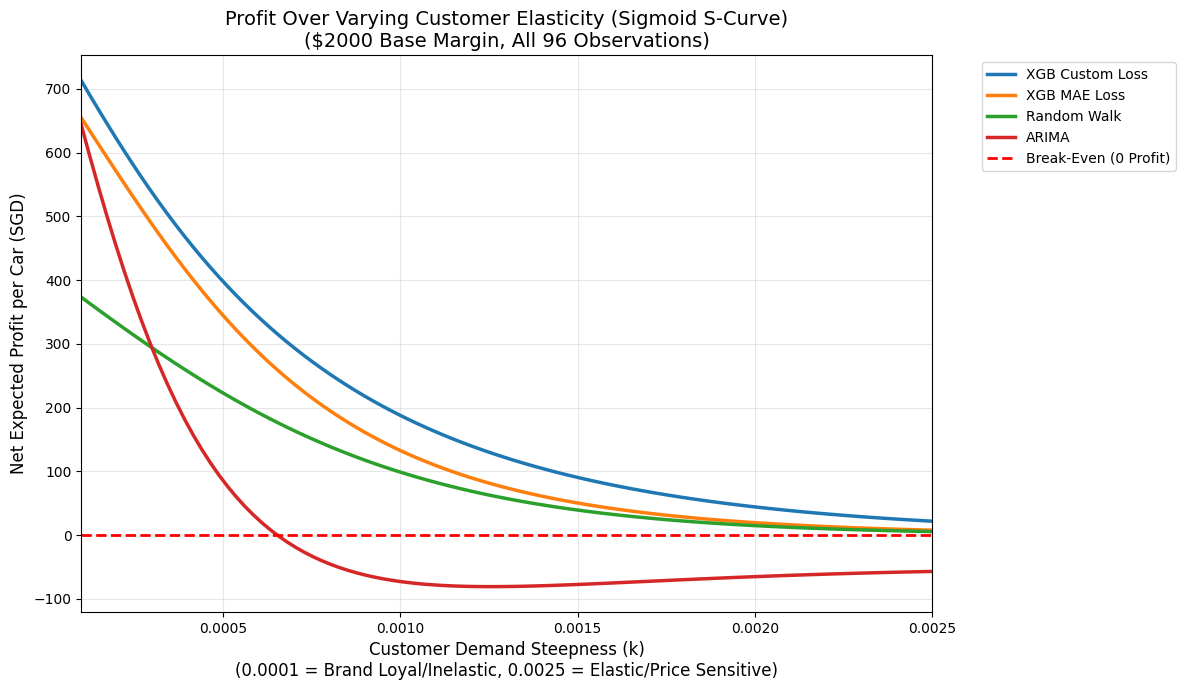

In [ ]:
plot_profit_curves_sigmoid(
    actual_levels=actual_levels_test,
    prev_levels=prev_levels_test,
    models_dict={
        "XGB Custom Loss": {"preds": xgb_pred_sigmoid_levels, "color": "tab:blue"},
        "XGB MAE Loss": {"preds": xgb_pred_levels, "color": "tab:orange"},
        "Random Walk": {"preds": rw_pred, "color": "tab:green"},
        "ARIMA": {"preds": arima_pred_levels, "color": "tab:red"},
    },
    base_margin=2000)

In [ ]:
profit_xgb = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
)
profit_xgb_sigmoid = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_sigmoid_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)
profit_rw = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=rw_pred,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)
profit_arima = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=arima_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)

In [ ]:
# 1. Calculate the difference in profit for each auction
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
constant = np.ones(len(d))
model = sm.OLS(endog=d, exog=constant)
hac_results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# 4. Extract the Diebold-Mariano Statistic and P-Value
dm_stat = hac_results.tvalues[0]
p_value = hac_results.pvalues[0]

print(f"Mean Profit Difference (XGB - RW): ${d.mean():.2f}")
print(f"Diebold-Mariano Statistic: {dm_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Mean Profit Difference (XGB - RW): $88.95
Diebold-Mariano Statistic: 1.9712
P-Value: 0.0487


In [ ]:
# Calculate the profit differences
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
# Perform the Wilcoxon signed-rank test
statistic, p_value = wilcoxon(d, alternative='two-sided')
print(f"Wilcoxon signed-rank test statistic: {statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

Wilcoxon signed-rank test statistic: 1624.0000
P-Value: 0.0149


In [ ]:
xgb_base_params = dict(
    lags=12,                 
    lags_past_covariates=12,  
    output_chunk_length=1,
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
)

xgb_param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 300],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "reg_alpha": [0.1, 0.3, 0.5],
}

xgb_pred, xgb_model = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,    # trees don't need scaling
    scale_target=False,
    n_splits=3,
    scoring_metric=mean_absolute_error,
    validation_refit_each_step=False
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'reg_alpha': 0.1, 'subsample': 0.8}


In [ ]:
xgb_base_params_sigmoid = dict(
    lags=12,
    lags_past_covariates=12,
    output_chunk_length=1,
    n_estimators=800,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42,
    objective="reg:absoluteerror",
)

xgb_pred_sigmoid, xgb_model_sigmoid = darts_pipeline(
    model_cls=XGBModel,
    base_params=xgb_base_params_sigmoid,
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
    param_grid=xgb_param_grid,
    scale_features=False,
    scale_target=False,
    n_splits=3,
    scoring_metric=lambda yt, yp: profit_cv_score_sigmoid(
        y_true_growth=yt,
        y_pred_growth=yp,
        prev_levels_lookup=prev_levels_train, 
        steepness=0.0005,      
        max_demand=1,        
        base_margin=2000
    ),
    validation_refit_each_step=False,
)

--- initial tuning (past_covariates only) ---
best_params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 7, 'n_estimators': 200, 'reg_alpha': 0.1, 'subsample': 1.0}


In [ ]:
from darts import TimeSeries
from darts.models import Chronos2Model
from darts.metrics import mae, rmse, mape

In [ ]:
enet_eval = evaluation(
    model_name="Elastic_Net",
    y_true=y_test,
    y_pred=enet_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

xgb_eval = evaluation(
    model_name="XGB",
    y_true=y_test,
    y_pred=xgb_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

rf_eval = evaluation(
    model_name="RF",
    y_true=y_test,
    y_pred=rf_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)

svr_eval = evaluation(
    model_name="SVR",
    y_true=y_test,
    y_pred=svr_pred,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)


xgb_eval_sigmoid = evaluation(
    model_name="XGB Custom Loss",
    y_true=y_test,
    y_pred=xgb_pred_sigmoid,
    prev_levels_test=prev_levels_test,
    actual_levels_test=actual_levels_test,
)


eval_df = pd.concat([arima_eval, enet_eval, xgb_eval, rf_eval, svr_eval, xgb_eval_sigmoid], ignore_index=True)

RMSE in growth rates: 5.8371
MAE in growth rates: 4.0497
RMSE in absolute levels: 5263.1243
MAE in absolute levels: 3680.1845
RMSE in growth rates: 5.6105
MAE in growth rates: 4.0312
RMSE in absolute levels: 5035.4540
MAE in absolute levels: 3647.6761
RMSE in growth rates: 5.8293
MAE in growth rates: 4.1194
RMSE in absolute levels: 5177.3469
MAE in absolute levels: 3733.3866
RMSE in growth rates: 5.8493
MAE in growth rates: 4.1361
RMSE in absolute levels: 5230.2026
MAE in absolute levels: 3755.0130
RMSE in growth rates: 5.5361
MAE in growth rates: 3.9765
RMSE in absolute levels: 4987.9457
MAE in absolute levels: 3612.0761


In [ ]:
eval_df

,model,rmse_growth,mae_growth,rmse_levels,mae_levels
0,AutoARIMA,5.927428,4.144671,5415.169745,3760.740040
1,Elastic_Net,5.837063,4.049707,5263.124270,3680.184458
2,XGB,5.610477,4.031191,5035.453982,3647.676141
3,RF,5.829269,4.119351,5177.346946,3733.386593
4,SVR,5.849269,4.136145,5230.202645,3755.012964
5,XGB Custom Loss,5.536140,3.976540,4987.945701,3612.076116


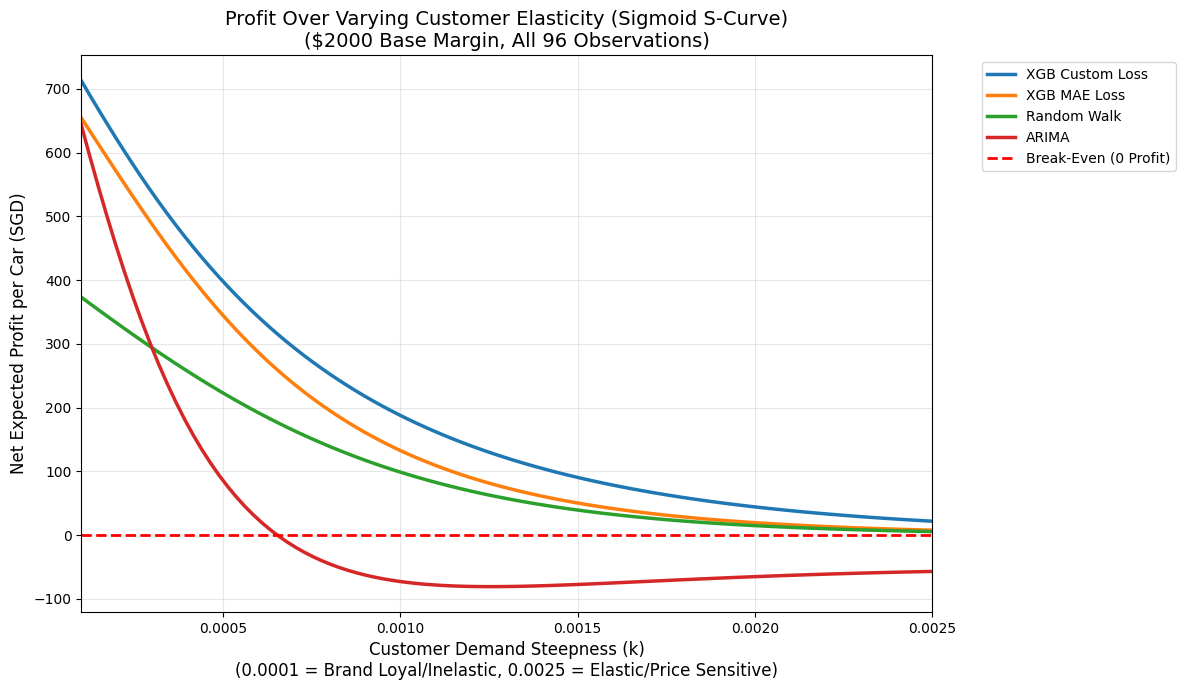

In [ ]:
plot_profit_curves_sigmoid(
    actual_levels=actual_levels_test,
    prev_levels=prev_levels_test,
    models_dict={
        "XGB Custom Loss": {"preds": xgb_pred_sigmoid_levels, "color": "tab:blue"},
        "XGB MAE Loss": {"preds": xgb_pred_levels, "color": "tab:orange"},
        "Random Walk": {"preds": rw_pred, "color": "tab:green"},
        "ARIMA": {"preds": arima_pred_levels, "color": "tab:red"},
    },
    base_margin=2000)

In [ ]:
profit_xgb = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
)
profit_xgb_sigmoid = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_sigmoid_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)
profit_rw = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=rw_pred,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)
profit_arima = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=arima_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.001,
    base_margin=2000,
    full_list=True
)

In [ ]:
# 1. Calculate the difference in profit for each auction
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
constant = np.ones(len(d))
model = sm.OLS(endog=d, exog=constant)
hac_results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# 4. Extract the Diebold-Mariano Statistic and P-Value
dm_stat = hac_results.tvalues[0]
p_value = hac_results.pvalues[0]

print(f"Mean Profit Difference (XGB - RW): ${d.mean():.2f}")
print(f"Diebold-Mariano Statistic: {dm_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Mean Profit Difference (XGB - RW): $88.95
Diebold-Mariano Statistic: 1.9712
P-Value: 0.0487


In [ ]:
profit_xgb = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.0005,
    base_margin=2000,
)
profit_xgb_sigmoid = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=xgb_pred_sigmoid_levels,
    prev_levels=prev_levels_test,
    steepness=0.0005,
    base_margin=2000,
    full_list=True
)
profit_rw = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=rw_pred,
    prev_levels=prev_levels_test,
    steepness=0.0005,
    base_margin=2000,
    full_list=True
)
profit_arima = mean_expected_profit_sigmoid(
    actual=actual_levels_test,
    pred=arima_pred_levels,
    prev_levels=prev_levels_test,
    steepness=0.0005,
    base_margin=2000,
    full_list=True
)

In [ ]:
# 1. Calculate the difference in profit for each auction
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
constant = np.ones(len(d))
model = sm.OLS(endog=d, exog=constant)
hac_results = model.fit(cov_type='HAC', cov_kwds={'maxlags': 1})

# 4. Extract the Diebold-Mariano Statistic and P-Value
dm_stat = hac_results.tvalues[0]
p_value = hac_results.pvalues[0]

print(f"Mean Profit Difference (XGB - RW): ${d.mean():.2f}")
print(f"Diebold-Mariano Statistic: {dm_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

Mean Profit Difference (XGB - RW): $174.85
Diebold-Mariano Statistic: 2.7677
P-Value: 0.0056


In [1]:
# Calculate the profit differences
d = np.array(profit_xgb_sigmoid) - np.array(profit_rw)
# Perform the Wilcoxon signed-rank test
statistic, p_value = wilcoxon(d, alternative='two-sided')
print(f"Wilcoxon signed-rank test statistic: {statistic:.4f}")
print(f"P-Value: {p_value:.4f}")

NameError: name 'np' is not defined

ImportError: The `(Py)Torch` module could not be imported. To enable (Py)Torch support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md


ImportError: The `(Py)Torch` module could not be imported. To enable (Py)Torch support in Darts, follow the detailed instructions in the installation guide: https://github.com/unit8co/darts/blob/master/INSTALL.md